# Ch01 Transformer Architecture — Solutions

This notebook explores key transformer components through hands-on experiments.

**Exercises**:
1. **Attention Pattern Visualization** — Extract and plot attention weights from a pretrained model
2. **Positional Encoding Comparison** — Compare sinusoidal vs learned positional embeddings
3. **Encoder vs Decoder Embeddings** — Compare semantic similarity from BERT and GPT-2

**Requirements**: `transformers`, `torch`, `matplotlib`, `seaborn`, `scikit-learn`

In [1]:
# Import Required Libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics.pairwise import cosine_similarity

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✓ Libraries imported")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

c:\repos\ai-portfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Libraries imported
PyTorch version: 2.11.0+cpu
Device: cpu


## Exercise 1: Attention Pattern Visualization

**Goal**: Visualize how attention heads focus on different parts of a sentence.

**Task**:
1. Load `distilbert-base-uncased` from Hugging Face
2. Process the sentence: "The river bank was flooded"
3. Extract attention weights from layer 0
4. Plot attention heatmaps for different heads
5. Analyze which heads focus on which token relationships

**Expected**: Different heads should show different attention patterns (some focus on adjacent tokens, others on syntactic dependencies)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8156.95it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentence: The river bank was flooded
Tokens: ['[CLS]', 'the', 'river', 'bank', 'was', 'flooded', '[SEP]']

Attention shape: torch.Size([12, 7, 7])
Number of heads: 12


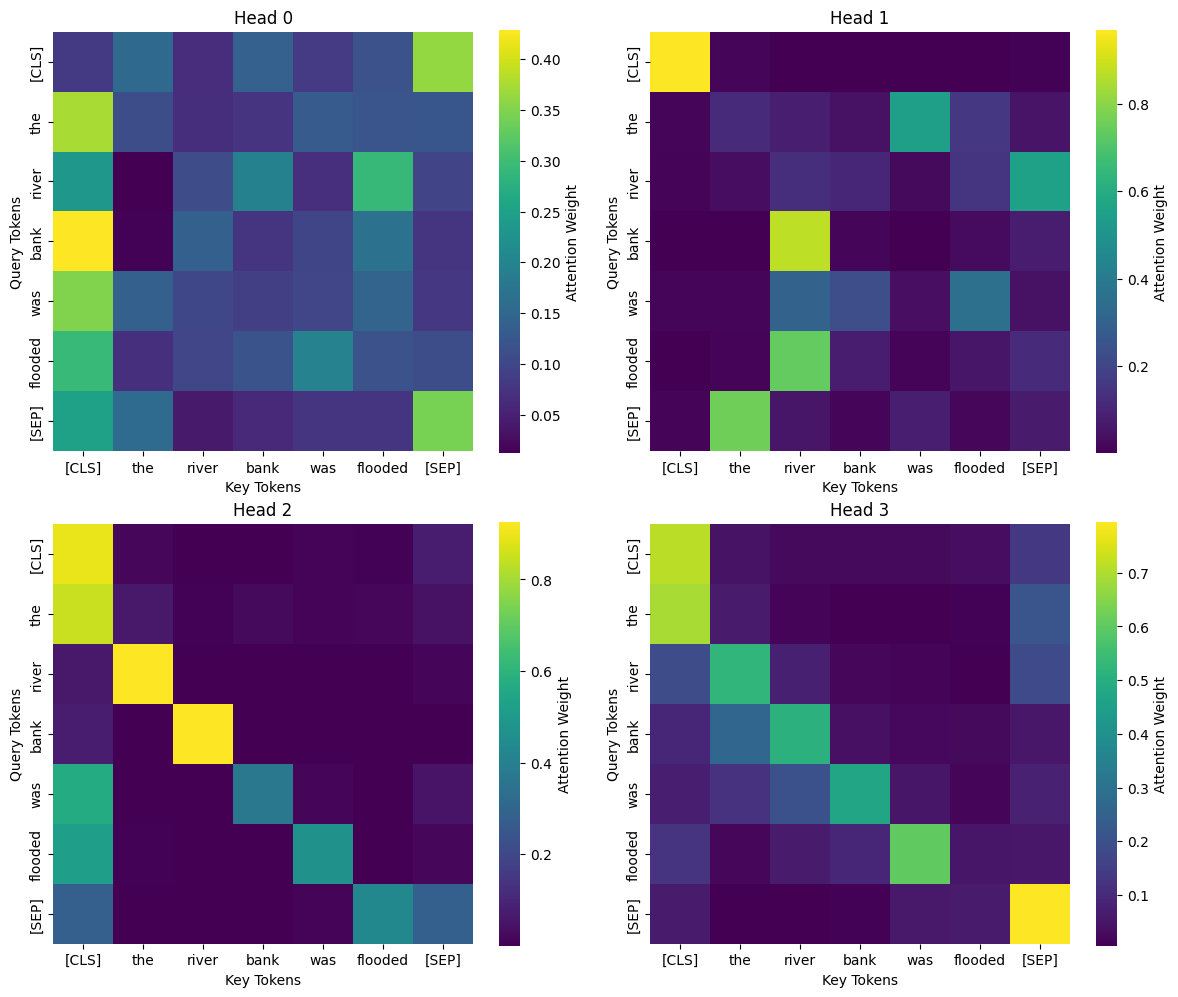


Attention Analysis for 'bank' (position 3)

Head 0 — 'bank' attends to:
  1. [CLS]        (weight: 0.429)
  2. flooded      (weight: 0.169)
  3. river        (weight: 0.138)

Head 1 — 'bank' attends to:
  1. river        (weight: 0.873)
  2. [SEP]        (weight: 0.079)
  3. flooded      (weight: 0.029)

Head 2 — 'bank' attends to:
  1. river        (weight: 0.924)
  2. [CLS]        (weight: 0.073)
  3. the          (weight: 0.001)

Head 3 — 'bank' attends to:
  1. river        (weight: 0.508)
  2. the          (weight: 0.265)
  3. [CLS]        (weight: 0.090)


In [2]:
# Load model and tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)
model.eval()

# Tokenize sentence
sentence = "The river bank was flooded"
inputs = tokenizer(sentence, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

print(f"Sentence: {sentence}")
print(f"Tokens: {tokens}")

# Forward pass
with torch.no_grad():
    outputs = model(**inputs)

# Extract attention weights from layer 0
# Shape: [batch, num_heads, seq_len, seq_len]
attention = outputs.attentions[0][0]  # Remove batch dimension
num_heads = attention.shape[0]

print(f"\nAttention shape: {attention.shape}")
print(f"Number of heads: {num_heads}")

# Plot attention heatmaps for first 4 heads
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for head_idx in range(4):
    ax = axes[head_idx]
    attn_matrix = attention[head_idx].numpy()

    sns.heatmap(
        attn_matrix,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='viridis',
        ax=ax,
        cbar_kws={'label': 'Attention Weight'},
        square=True
    )
    ax.set_title(f'Head {head_idx}')
    ax.set_xlabel('Key Tokens')
    ax.set_ylabel('Query Tokens')

plt.tight_layout()
plt.savefig('attention_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# Analyze attention on "bank" token (index 3)
bank_idx = 3
print(f"\n{'='*60}")
print(f"Attention Analysis for 'bank' (position {bank_idx})")
print('='*60)

for head_idx in range(4):
    attn_on_bank = attention[head_idx, bank_idx, :].numpy()
    top3_indices = np.argsort(attn_on_bank)[-3:][::-1]

    print(f"\nHead {head_idx} — 'bank' attends to:")
    for rank, idx in enumerate(top3_indices, 1):
        print(f"  {rank}. {tokens[idx]:12s} (weight: {attn_on_bank[idx]:.3f})")

## Exercise 2: Positional Encoding Comparison

**Goal**: Compare sinusoidal (fixed) vs learned positional encodings for position extrapolation.

**Task**:
1. Implement sinusoidal positional encoding (PE) function
2. Load a model with learned positional embeddings (distilbert uses learned)
3. Test position extrapolation:
   - Models typically train on max_position_embeddings (e.g., 512)
   - Test behavior when positions exceed training range (e.g., 1024)
4. Compare: Can sinusoidal PE extrapolate beyond training positions?

**Expected**: Sinusoidal PE should generalize to longer sequences; learned embeddings may degrade

In [ ]:
def sinusoidal_pe(seq_len, d_model):
    """
    Generate sinusoidal positional encodings.

    Args:
        seq_len: Sequence length (number of positions)
        d_model: Model dimension (embedding size)

    Returns:
        PE of shape [seq_len, d_model]
    """
    pe = np.zeros((seq_len, d_model))
    position = np.arange(seq_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

    # Apply sin to even indices
    pe[:, 0::2] = np.sin(position * div_term)
    # Apply cos to odd indices
    pe[:, 1::2] = np.cos(position * div_term)

    return pe

# Generate sinusoidal PE for positions 0-1023
d_model = 768
max_train_pos = 512
max_test_pos = 1024

sinusoidal_embeddings = sinusoidal_pe(max_test_pos, d_model)
print(f"Sinusoidal PE shape: {sinusoidal_embeddings.shape}")

# Load DistilBERT and extract learned position embeddings
model = AutoModel.from_pretrained("distilbert-base-uncased")
learned_embeddings = model.embeddings.position_embeddings.weight.detach().numpy()
print(f"Learned PE shape: {learned_embeddings.shape}")
print(f"Max position embeddings (trained): {learned_embeddings.shape[0]}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: First 8 dimensions over all positions
dims_to_plot = 8
for dim in range(dims_to_plot):
    axes[0].plot(sinusoidal_embeddings[:max_train_pos, dim],
                 alpha=0.7, label=f'Dim {dim}' if dim < 4 else None)
axes[0].axvline(x=max_train_pos, color='red', linestyle='--',
                label='Training limit')
axes[0].set_title('Sinusoidal PE (generalizes beyond training)')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Embedding Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Learned embeddings (only up to max_position_embeddings)
for dim in range(dims_to_plot):
    axes[1].plot(learned_embeddings[:, dim], alpha=0.7,
                 label=f'Dim {dim}' if dim < 4 else None)
axes[1].set_title('Learned PE (stops at training limit)')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Embedding Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('positional_encoding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Demonstrate extrapolation behavior
print("\n" + "="*60)
print("Positional Encoding Extrapolation Test")
print("="*60)
print(f"Sinusoidal PE: Can encode positions 0-{max_test_pos}")
print(f"Learned PE: Trained only on positions 0-{max_train_pos}")
print("\nKey difference:")
print("- Sinusoidal: Deterministic formula → extrapolates smoothly")
print("- Learned: Fixed lookup table → requires retraining for longer sequences")

## Exercise 3: Encoder vs Decoder Embeddings

**Goal**: Compare semantic similarity from BERT (encoder-only) vs GPT-2 (decoder-only).

**Task**:
1. Load BERT (`bert-base-uncased`) and GPT-2 (`gpt2`)
2. Create 10 sentence pairs with varying semantic similarity
3. For each model:
   - Encode sentences (use [CLS] token for BERT, last token for GPT-2)
   - Compute cosine similarity between pair embeddings
4. Compare which model produces better semantic similarity scores

**Expected**: BERT should produce higher similarity for related pairs (trained on MLM + NSP)

In [ ]:
# Define sentence pairs with ground-truth similarity
sentence_pairs = [
    ("The cat sat on the mat", "A feline rested on the rug", "high"),
    ("I love machine learning", "Pizza is delicious", "low"),
    ("Transformers use self-attention", "BERT employs attention mechanisms", "high"),
    ("The weather is sunny today", "It's raining heavily outside", "low"),
    ("Python is a programming language", "Java is used for software development", "medium"),
    ("Neural networks learn from data", "Deep learning models require training", "high"),
    ("I enjoy reading books", "The stock market crashed yesterday", "low"),
    ("Cars drive on roads", "Vehicles travel on highways", "high"),
    ("She plays the piano beautifully", "He excels at playing guitar", "medium"),
    ("Quantum computing is revolutionary", "Cooking pasta requires boiling water", "low")
]

print(f"Testing {len(sentence_pairs)} sentence pairs")
print("="*80)

# Load BERT
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased")
bert_model.eval()

# Load GPT-2
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")
gpt2_model = AutoModel.from_pretrained("gpt2")
gpt2_model.eval()

# GPT-2 doesn't have a padding token, set it to EOS
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

results = []

for sent1, sent2, ground_truth in sentence_pairs:
    # BERT encoding (use [CLS] token)
    bert_inputs1 = bert_tokenizer(sent1, return_tensors="pt", padding=True, truncation=True)
    bert_inputs2 = bert_tokenizer(sent2, return_tensors="pt", padding=True, truncation=True)

    with torch.no_grad():
        bert_outputs1 = bert_model(**bert_inputs1)
        bert_outputs2 = bert_model(**bert_inputs2)

    # Extract [CLS] token embeddings (first token)
    bert_emb1 = bert_outputs1.last_hidden_state[:, 0, :].numpy()
    bert_emb2 = bert_outputs2.last_hidden_state[:, 0, :].numpy()
    bert_similarity = cosine_similarity(bert_emb1, bert_emb2)[0][0]

    # GPT-2 encoding (use last token)
    gpt2_inputs1 = gpt2_tokenizer(sent1, return_tensors="pt", padding=True, truncation=True)
    gpt2_inputs2 = gpt2_tokenizer(sent2, return_tensors="pt", padding=True, truncation=True)

    with torch.no_grad():
        gpt2_outputs1 = gpt2_model(**gpt2_inputs1)
        gpt2_outputs2 = gpt2_model(**gpt2_inputs2)

    # Extract last token embeddings
    gpt2_emb1 = gpt2_outputs1.last_hidden_state[:, -1, :].numpy()
    gpt2_emb2 = gpt2_outputs2.last_hidden_state[:, -1, :].numpy()
    gpt2_similarity = cosine_similarity(gpt2_emb1, gpt2_emb2)[0][0]

    results.append({
        'sent1': sent1,
        'sent2': sent2,
        'ground_truth': ground_truth,
        'bert_sim': bert_similarity,
        'gpt2_sim': gpt2_similarity
    })

# Print comparison table
print("\n" + "="*80)
print("SEMANTIC SIMILARITY COMPARISON")
print("="*80)
print(f"{'Sentence 1':<35} {'Sentence 2':<35} {'Truth':<8} {'BERT':<8} {'GPT-2':<8}")
print("-"*80)

for r in results:
    sent1_short = r['sent1'][:32] + "..." if len(r['sent1']) > 32 else r['sent1']
    sent2_short = r['sent2'][:32] + "..." if len(r['sent2']) > 32 else r['sent2']
    print(f"{sent1_short:<35} {sent2_short:<35} {r['ground_truth']:<8} "
          f"{r['bert_sim']:<8.3f} {r['gpt2_sim']:<8.3f}")

# Compute average similarities by ground truth category
print("\n" + "="*80)
print("AVERAGE SIMILARITIES BY CATEGORY")
print("="*80)

for category in ['high', 'medium', 'low']:
    category_results = [r for r in results if r['ground_truth'] == category]
    if category_results:
        avg_bert = np.mean([r['bert_sim'] for r in category_results])
        avg_gpt2 = np.mean([r['gpt2_sim'] for r in category_results])
        print(f"{category.upper():<8} | BERT: {avg_bert:.3f} | GPT-2: {avg_gpt2:.3f}")

print("\n" + "="*80)
print("ANALYSIS")
print("="*80)
print("BERT (Encoder):")
print("  ✓ Bidirectional context → better semantic understanding")
print("  ✓ Trained on Masked LM + Next Sentence Prediction")
print("  ✓ [CLS] token aggregates sentence meaning")
print("\nGPT-2 (Decoder):")
print("  • Causal masking → only left context")
print("  • Trained on autoregressive generation (not similarity)")
print("  • Last token may not capture full sentence meaning")
print("\nConclusion: BERT produces better semantic embeddings for similarity tasks")

## Summary

**Key Takeaways**:
1. **Attention**: Different heads capture different linguistic relationships (adjacency, syntax, semantics)
2. **Positional Encoding**: Sinusoidal PE generalizes to unseen positions; learned PE requires retraining
3. **Encoder vs Decoder**: BERT's bidirectional context produces better semantic embeddings than GPT-2's causal masking

**Next Steps**:
- Experiment with different layers (deeper layers = more abstract patterns)
- Try other models (RoBERTa, ALBERT, T5)
- Test attention on longer sequences or different languages
- Explore relative positional encodings (T5, Transformer-XL)